In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("merged_staging_claims_patient_level.csv")

df

,member_number,total_cost,total_util,first_claim_day,last_claim_day,time_since_first_claim,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,...,RX,Unknown,ICD10_CODE,MOST_RECENT_PATH_STAGE_DT,MOST_RECENT_CLINICAL_STAGE_DT,PATHOLOGIC_STAGE_GROUP,CLINICAL_STAGE_GROUP,ICD10_group,cancer_type,FINAL_STAGE
0,A001,34347.750000,3635.000000,-364,1,365,0.000000,0.0,6479.460000,0.000000,...,8469.430000,0.0,C50.111,203.0,25.0,Stage IIA,Stage IIIB,C50,breast,Stage IIA
1,A002,510592.723295,4924.408844,-357,1248,1605,11121.566358,0.0,42436.993906,0.000000,...,10207.796862,0.0,C50.412,110.0,NaN,Stage IA,NaN,C50,breast,Stage IA
2,A003,292610.070000,23653.000000,-364,1580,1944,0.000000,0.0,0.000000,0.000000,...,106422.650000,0.0,C50.412,755.0,NaN,Stage IA,NaN,C50,breast,Stage IA
3,A004,1570.130976,891.586289,-14,195,209,0.000000,0.0,0.000000,0.000000,...,199.239501,0.0,C50.812,NaN,-2843.0,NaN,Stage IIA,C50,breast,Stage IIA
4,A005,205847.259905,7610.727996,-364,1026,1390,0.000000,0.0,0.000000,16040.090286,...,11823.801367,0.0,C18.7,80.0,NaN,Stage I,NaN,C18,colorectal,Stage I
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3652,D656,631.394078,157.596808,-41,2,43,0.000000,0.0,0.000000,0.000000,...,30.333981,0.0,C18.4,-183.0,NaN,Stage IIA,NaN,C18,colorectal,Stage IIA
3653,D657,58470.372278,1190.183009,-1,111,112,0.000000,0.0,0.000000,0.000000,...,1820.672344,0.0,C34.12,NaN,4.0,NaN,Stage IIIA,C34,lung,Stage IIIA
3654,D658,20523.930877,95.685192,0,97,97,0.000000,0.0,0.000000,0.000000,...,837.082614,0.0,C18.7,34.0,NaN,Stage IIA,NaN,C18,colorectal,Stage IIA
3655,D659,57216.047114,391.365529,0,104,104,0.000000,0.0,0.000000,0.000000,...,110.582363,0.0,C50.511,39.0,NaN,Stage IA,NaN,C50,breast,Stage IA


In [17]:
df.columns

Index(['member_number', 'total_cost', 'total_util', 'first_claim_day',
       'last_claim_day', 'time_since_first_claim', 'IP Behavioral Health',
       'IP Maternity', 'IP Medical', 'IP SNF', 'IP Surgical',
       'OP Behavioral Health', 'OP ER', 'OP Observation', 'OP Other',
       'OP Path/Lab', 'OP Pharmacy', 'OP Radiology', 'OP Surgery',
       'PDN/Home Health', 'Prof Invisible Prov Procedures', 'Prof Other',
       'Prof PCP Procedures', 'Prof Specialist Procedures', 'RX', 'Unknown',
       'ICD10_CODE', 'MOST_RECENT_PATH_STAGE_DT',
       'MOST_RECENT_CLINICAL_STAGE_DT', 'PATHOLOGIC_STAGE_GROUP',
       'CLINICAL_STAGE_GROUP', 'ICD10_group', 'cancer_type', 'FINAL_STAGE'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3657 entries, 0 to 3656
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   member_number                   3657 non-null   object 
 1   total_cost                      3657 non-null   float64
 2   total_util                      3657 non-null   float64
 3   first_claim_day                 3657 non-null   int64  
 4   last_claim_day                  3657 non-null   int64  
 5   time_since_first_claim          3657 non-null   int64  
 6   IP Behavioral Health            3657 non-null   float64
 7   IP Maternity                    3657 non-null   float64
 8   IP Medical                      3657 non-null   float64
 9   IP SNF                          3657 non-null   float64
 10  IP Surgical                     3657 non-null   float64
 11  OP Behavioral Health            3657 non-null   float64
 12  OP ER                           36

In [19]:
# drop rows with missing FINAL_STAGE in place
df.dropna(subset=["FINAL_STAGE"], inplace=True)

In [20]:
# missingness by column
missingness = df.isnull().mean() * 100
missingness

member_number                      0.000000
total_cost                         0.000000
total_util                         0.000000
first_claim_day                    0.000000
last_claim_day                     0.000000
time_since_first_claim             0.000000
IP Behavioral Health               0.000000
IP Maternity                       0.000000
IP Medical                         0.000000
IP SNF                             0.000000
IP Surgical                        0.000000
OP Behavioral Health               0.000000
OP ER                              0.000000
OP Observation                     0.000000
OP Other                           0.000000
OP Path/Lab                        0.000000
OP Pharmacy                        0.000000
OP Radiology                       0.000000
OP Surgery                         0.000000
PDN/Home Health                    0.000000
Prof Invisible Prov Procedures     0.000000
Prof Other                         0.000000
Prof PCP Procedures             

In [21]:
df.describe()

,total_cost,total_util,first_claim_day,last_claim_day,time_since_first_claim,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,IP Surgical,...,OP Surgery,PDN/Home Health,Prof Invisible Prov Procedures,Prof Other,Prof PCP Procedures,Prof Specialist Procedures,RX,Unknown,MOST_RECENT_PATH_STAGE_DT,MOST_RECENT_CLINICAL_STAGE_DT
count,3.550000e+03,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,...,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3.550000e+03,3.550000e+03,3550.000000,1810.000000,2172.000000
mean,1.833475e+05,5686.244150,-252.185070,1388.606197,1640.791268,202.417403,43.700077,6796.202631,815.744043,14375.335157,...,18179.178961,2277.290641,4310.784113,2256.668853,2629.134210,2.182128e+04,2.780858e+04,0.088732,94.560773,107.036372
std,2.637969e+05,6358.418638,137.475516,1007.872358,1021.568225,3124.641305,742.920986,20665.098647,4086.442360,31373.351611,...,25112.123569,5803.774478,3426.348865,5126.411114,5163.318201,6.494275e+04,8.726457e+04,5.286843,650.766063,627.836796
min,0.000000e+00,0.000000,-366.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,-0.071390,0.000000,0.000000e+00,0.000000e+00,0.000000,-3089.000000,-3106.000000
25%,5.359302e+04,1063.735479,-359.000000,515.000000,755.250000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3687.202500,0.000000,2069.783338,0.000000,859.574223,8.142381e+03,6.545684e+02,0.000000,23.000000,0.000000
50%,1.048952e+05,3548.062440,-337.000000,1197.000000,1467.500000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10498.136328,0.000000,3587.721507,446.282786,1845.540676,1.498667e+04,4.091692e+03,0.000000,53.000000,29.000000
75%,2.062048e+05,8179.432976,-126.000000,2150.000000,2450.000000,0.000000,0.000000,6047.980000,0.000000,18974.374209,...,22706.930178,2225.175001,5644.591991,2290.025013,3419.839421,2.461039e+04,1.853748e+04,0.000000,140.000000,120.250000
max,3.780082e+06,49826.027187,0.000000,3819.000000,3984.000000,83974.112946,25068.916081,450604.822426,83019.134115,756927.964745,...,485518.184601,76923.416384,40932.653785,111040.381897,269290.307888,3.114806e+06,1.261810e+06,315.000000,3482.000000,3613.000000


In [22]:
# Convert days to months
df["months_since_dx"] = df["time_since_first_claim"] / 30

# Create 3-month buckets
df["quarter_bucket"] = (df["months_since_dx"] // 3).astype(int)

In [23]:
cost_trend = (
    df.groupby("quarter_bucket")["total_cost"]
    .mean()
    .reset_index()
)


In [24]:
util_trend = (
    df.groupby("quarter_bucket")["total_util"]
    .mean()
    .reset_index()
)


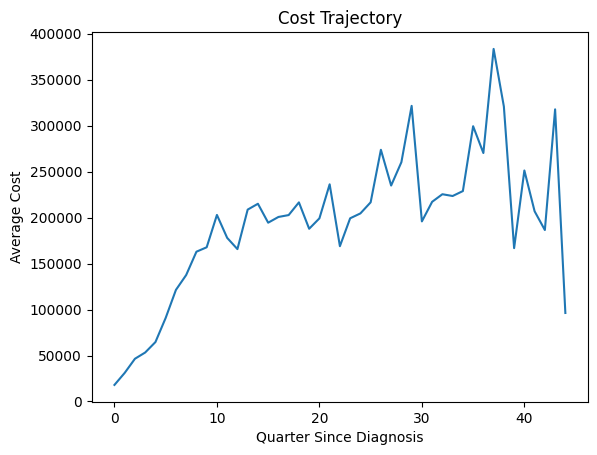

In [26]:
plt.figure()
plt.plot(cost_trend["quarter_bucket"], cost_trend["total_cost"])
plt.xlabel("Quarter Since Diagnosis")
plt.ylabel("Average Cost")
plt.title("Cost Trajectory")
plt.show()


In [29]:
summary_clean = (
    df.groupby("cancer_type")
    .agg(
        avg_cost=("total_cost", "mean"),
        median_cost=("total_cost", "median"),
        avg_util=("total_util", "mean"),
        avg_followup_days=("last_claim_day", "mean"),
        n_patients=("member_number", "nunique")
    )
    .reset_index()
)

summary_clean


,cancer_type,avg_cost,median_cost,avg_util,avg_followup_days,n_patients
0,breast,171388.237186,97195.646224,5973.705018,1534.918610,2187
1,colorectal,171252.560850,112578.959394,4539.024028,1254.734551,712
2,lung,236752.489910,121525.811919,5975.251535,1043.493088,651


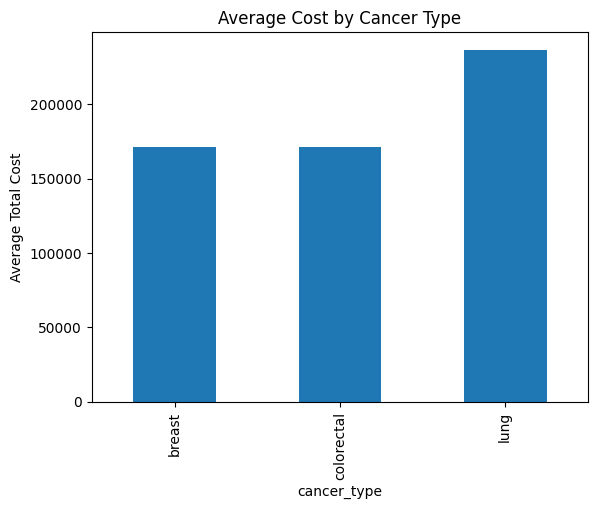

In [30]:
cost_means = df.groupby("cancer_type")["total_cost"].mean()

plt.figure()
cost_means.plot(kind="bar")
plt.ylabel("Average Total Cost")
plt.title("Average Cost by Cancer Type")
plt.show()

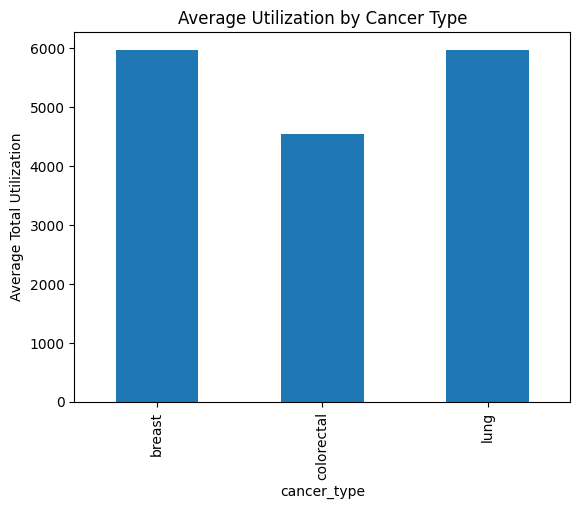

In [31]:
util_means = df.groupby("cancer_type")["total_util"].mean()

plt.figure()
util_means.plot(kind="bar")
plt.ylabel("Average Total Utilization")
plt.title("Average Utilization by Cancer Type")
plt.show()


In [32]:
cost_cols = [
    "IP Behavioral Health",
    "IP Maternity",
    "IP Medical",
    "IP SNF",
    "IP Surgical",
    "OP Behavioral Health",
    "OP ER",
    "OP Observation",
    "OP Other",
    "OP Path/Lab",
    "OP Pharmacy",
    "OP Radiology",
    "OP Surgery",
    "PDN/Home Health",
    "Prof Invisible Prov Procedures",
    "Prof Other",
    "Prof PCP Procedures",
    "Prof Specialist Procedures",
    "RX",
    "Unknown"
]


In [33]:
spend_by_cancer = (
    df.groupby("cancer_type")[cost_cols]
    .mean()
    .reset_index()
)

spend_by_cancer


,cancer_type,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,IP Surgical,OP Behavioral Health,OP ER,OP Observation,OP Other,...,OP Pharmacy,OP Radiology,OP Surgery,PDN/Home Health,Prof Invisible Prov Procedures,Prof Other,Prof PCP Procedures,Prof Specialist Procedures,RX,Unknown
0,breast,235.044291,68.917652,4265.697439,652.479227,6349.467337,34.697143,1485.003071,1171.071735,4787.526754,...,58547.022285,11343.625646,21904.591812,1148.497396,4029.212112,2175.385167,2543.802508,21398.410922,27918.351617,0.144033
1,colorectal,140.361978,6.197149,10707.066098,1062.071648,32259.674185,4.995694,1848.738572,1699.796364,5077.521247,...,39729.619942,10604.353828,12397.241534,5218.079450,4799.672839,2410.757816,2651.961434,22848.692870,16064.999639,0.000000
2,lung,160.679245,0.000000,11019.981535,1094.814548,21777.675452,29.929950,1595.611483,1683.404028,3894.498839,...,91278.942013,15491.866026,11987.568427,2853.065134,4722.011756,2361.209682,2890.835360,22118.185254,40283.802943,0.000000


In [34]:
# compute mean total cost by cancer
mean_total = df.groupby("cancer_type")["total_cost"].mean()

# divide category means by total cost
spend_pct = (
    df.groupby("cancer_type")[cost_cols]
    .mean()
    .div(mean_total, axis=0)
    * 100
)

spend_pct.reset_index()


,cancer_type,IP Behavioral Health,IP Maternity,IP Medical,IP SNF,IP Surgical,OP Behavioral Health,OP ER,OP Observation,OP Other,...,OP Pharmacy,OP Radiology,OP Surgery,PDN/Home Health,Prof Invisible Prov Procedures,Prof Other,Prof PCP Procedures,Prof Specialist Procedures,RX,Unknown
0,breast,0.137141,0.040211,2.488909,0.380702,3.704728,0.020245,0.866456,0.683286,2.793381,...,34.160467,6.618672,12.780686,0.670114,2.350927,1.269273,1.484234,12.485344,16.289538,0.000084
1,colorectal,0.081962,0.003619,6.252208,0.620179,18.837484,0.002917,1.079539,0.992567,2.964932,...,23.199431,6.192231,7.239157,3.047008,2.802687,1.407721,1.548567,13.342103,9.380881,0.000000
2,lung,0.067868,0.000000,4.654642,0.462430,9.198499,0.012642,0.673958,0.711040,1.644966,...,38.554586,6.543486,5.063334,1.205083,1.994493,0.997333,1.221037,9.342324,17.015155,0.000000


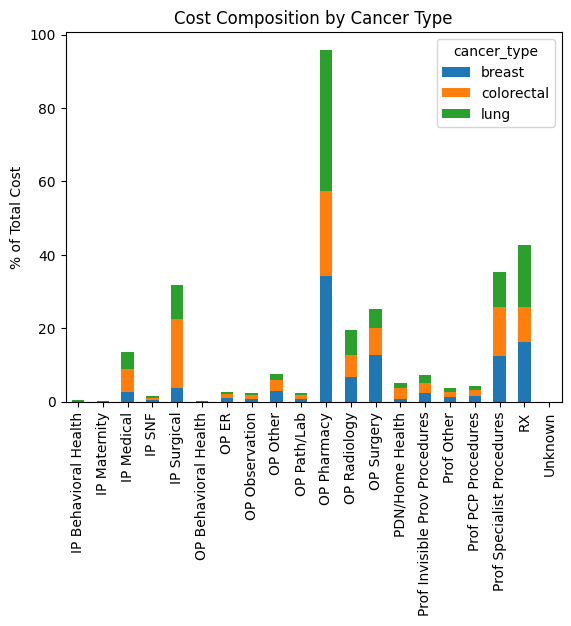

In [35]:
spend_pct.T.plot(kind="bar", stacked=True)
plt.ylabel("% of Total Cost")
plt.title("Cost Composition by Cancer Type")
plt.show()
